## Provider_and_Supplier_v02

This notebook is an extension of the original Provider_and_Supplier notebook.

(12/10/2025) The primary focus is to create a choropleth map and a bar chart showing Excluded NPI RUCA counts and the top HCPCS codes among excluded providers, to support data story development.

In [6]:
# Loading the required Libraries and Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



df=pd.read_csv("/dsa/groups/casestudycf25/team02/DMEPOS_RefPro_Ser_nar_clean.csv")



C:\Users\kamat\AppData\Local\Temp\ipykernel_21984\1775726209.py:8: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"D:\DATA\Project\Current focus\DMEPOS - By Referral Provider and Service\DMEPOS_RefPro_Ser_nar_clean.csv")


In [7]:
# Columns
df.columns

Index(['Year', 'Rfrg_NPI', 'Rfrg_Prvdr_Last_Name_Org', 'Rfrg_Prvdr_First_Name',
       'Rfrg_Prvdr_MI', 'Rfrg_Prvdr_Crdntls', 'Rfrg_Prvdr_Ent_Cd',
       'Rfrg_Prvdr_St1', 'Rfrg_Prvdr_St2', 'Rfrg_Prvdr_City',
       'Rfrg_Prvdr_State_Abrvtn', 'Rfrg_Prvdr_State_FIPS', 'Rfrg_Prvdr_Zip5',
       'Rfrg_Prvdr_RUCA_Cat', 'Rfrg_Prvdr_RUCA', 'Rfrg_Prvdr_RUCA_Desc',
       'Rfrg_Prvdr_Cntry', 'Rfrg_Prvdr_Spclty_Cd', 'Rfrg_Prvdr_Spclty_Desc',
       'Rfrg_Prvdr_Spclty_Srce', 'RBCS_Lvl', 'RBCS_Id', 'RBCS_Desc',
       'HCPCS_CD', 'HCPCS_Desc', 'Suplr_Rentl_Ind', 'Tot_Suplrs',
       'DME_Sprsn_Ind', 'Tot_Suplr_Benes', 'Tot_Suplr_Clms', 'Tot_Suplr_Srvcs',
       'Avg_Suplr_Sbmtd_Chrg', 'Avg_Suplr_Mdcr_Alowd_Amt',
       'Avg_Suplr_Mdcr_Pymt_Amt', 'Avg_Suplr_Mdcr_Stdzd_Amt', 'Excluded',
       'Supplier'],
      dtype='object')

In [8]:
#Shape
df.shape

(4413118, 37)

## Bar chart - RUCA Category count

In [9]:
# Focusing on Excluded NPIs
df["Rfrg_Prvdr_RUCA_Cat"] = df["Rfrg_Prvdr_RUCA_Cat"].astype("category")
suppressed_rows = df.loc[df["Excluded"] == "y", "Rfrg_Prvdr_RUCA_Cat"]
suppressed_by_ruca_cat = suppressed_rows.value_counts().reset_index(name="Suppressed_Count")
suppressed_by_ruca_cat

,Rfrg_Prvdr_RUCA_Cat,Suppressed_Count
0,urban,1222
1,rural,191
2,unknown,0


In [10]:
df_filtered = suppressed_by_ruca_cat
df_filtered

,Rfrg_Prvdr_RUCA_Cat,Suppressed_Count
0,urban,1222
1,rural,191
2,unknown,0


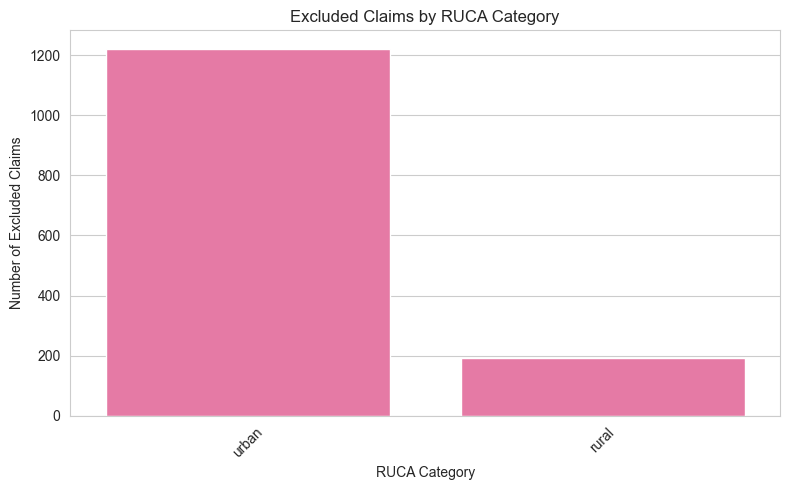

In [11]:
#Visual
df["Rfrg_Prvdr_RUCA_Cat"] = (
    df["Rfrg_Prvdr_RUCA_Cat"]
    .astype(str)
    .str.strip()
    .str.lower()
)
suppressed_rows = df.loc[df["Excluded"].str.lower() == "y", "Rfrg_Prvdr_RUCA_Cat"]
suppressed_by_ruca_cat = suppressed_rows.value_counts().reset_index(name="Suppressed_Count")
suppressed_by_ruca_cat.rename(columns={'index':'Rfrg_Prvdr_RUCA_Cat'}, inplace=True)

df_filtered = suppressed_by_ruca_cat[suppressed_by_ruca_cat['Rfrg_Prvdr_RUCA_Cat'] != 'unknown']
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_filtered,
    x='Rfrg_Prvdr_RUCA_Cat',
    y='Suppressed_Count',
    color='#f768a1'
)
plt.xlabel('RUCA Category')
plt.ylabel('Number of Excluded Claims')
plt.title('Excluded Claims by RUCA Category')
plt.xticks(rotation=45)
plt.tight_layout()

# Saving Image
plt.savefig("excluded_by_ruca.png", dpi=600, bbox_inches="tight")
plt.show()

In [12]:
df_filtered

,Rfrg_Prvdr_RUCA_Cat,Suppressed_Count
0,urban,1222
1,rural,191


## Top HCPCS Codes among Excluded Providers

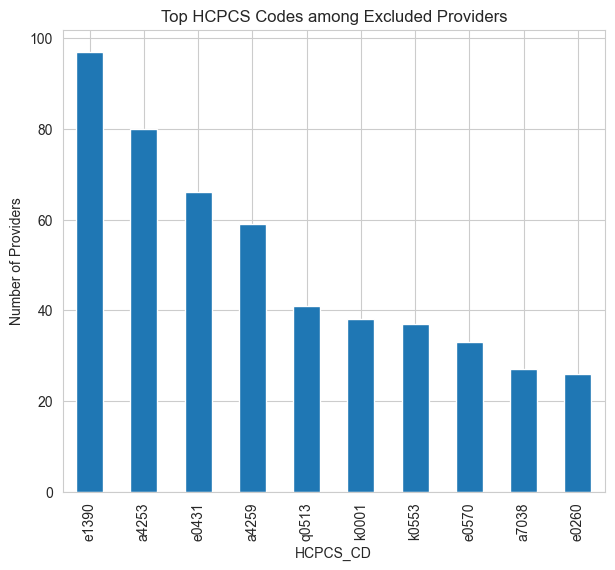

In [13]:
#  Visual

plt.figure(figsize=(7,6))
top_hcpcs = df[df['Excluded']=='y'].groupby('HCPCS_CD')['Rfrg_NPI'].count().sort_values(ascending=False).head(10)
top_hcpcs.plot(kind='bar')
plt.title('Top HCPCS Codes among Excluded Providers')
plt.ylabel('Number of Providers')
plt.show()

In [30]:
# Testing to see if certain HCPCS code is associated with fraud or is it just count (Null Hypothesis)

from scipy.stats import chi2_contingency

# Top 10 codes
top_codes = df[df['Excluded']=='y']['HCPCS_CD'].value_counts().head(10).index

#Only checking subset with top 10 codes
subset = df[df['HCPCS_CD'].isin(top_codes)]

# Create contingency table
contingency = pd.crosstab(subset['HCPCS_CD'], subset['Excluded'])

#Chi test
chi2, p, dof, expected = chi2_contingency(contingency)
print("Chi-square:", chi2, "p-value:", p)

Chi-square: 25.316390918851916 p-value: 0.002640418103224908


In [15]:
# Loading Exclusion data (Not needed)
d = pd.read_csv("/dsa/groups/casestudycf25/team02/leie_with_valid_npi_clean.csv",dtype={"Suplr_Prvdr_RUCA": "float64"},na_values=["NA"])

In [16]:
# Attribute names
df.columns


Index(['Year', 'Rfrg_NPI', 'Rfrg_Prvdr_Last_Name_Org', 'Rfrg_Prvdr_First_Name',
       'Rfrg_Prvdr_MI', 'Rfrg_Prvdr_Crdntls', 'Rfrg_Prvdr_Ent_Cd',
       'Rfrg_Prvdr_St1', 'Rfrg_Prvdr_St2', 'Rfrg_Prvdr_City',
       'Rfrg_Prvdr_State_Abrvtn', 'Rfrg_Prvdr_State_FIPS', 'Rfrg_Prvdr_Zip5',
       'Rfrg_Prvdr_RUCA_Cat', 'Rfrg_Prvdr_RUCA', 'Rfrg_Prvdr_RUCA_Desc',
       'Rfrg_Prvdr_Cntry', 'Rfrg_Prvdr_Spclty_Cd', 'Rfrg_Prvdr_Spclty_Desc',
       'Rfrg_Prvdr_Spclty_Srce', 'RBCS_Lvl', 'RBCS_Id', 'RBCS_Desc',
       'HCPCS_CD', 'HCPCS_Desc', 'Suplr_Rentl_Ind', 'Tot_Suplrs',
       'DME_Sprsn_Ind', 'Tot_Suplr_Benes', 'Tot_Suplr_Clms', 'Tot_Suplr_Srvcs',
       'Avg_Suplr_Sbmtd_Chrg', 'Avg_Suplr_Mdcr_Alowd_Amt',
       'Avg_Suplr_Mdcr_Pymt_Amt', 'Avg_Suplr_Mdcr_Stdzd_Amt', 'Excluded',
       'Supplier'],
      dtype='object')

## Choropleth Map

<Figure size 1200x800 with 0 Axes>

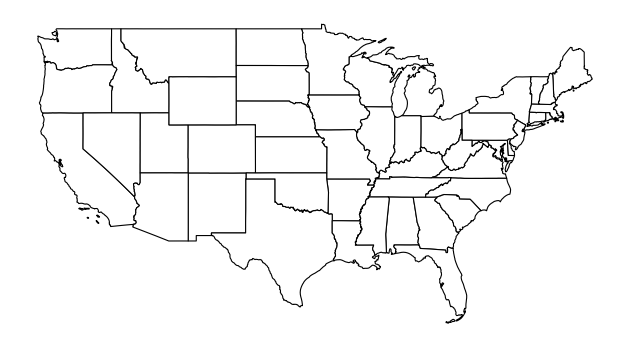

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt

#Loading clean US states shapefile from the Census TIGER dataset
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip"
)

#Drop Alaska, Hawaii, Puerto Rico
states = states[~states['STUSPS'].isin(['AK', 'HI', 'PR'])]

#Plot map
plt.figure(figsize=(12, 8))
states.plot(
    linewidth=0.8,
    edgecolor="black",
    facecolor="white"  # empty fill
)

plt.axis("off")
plt.tight_layout()
plt.show()


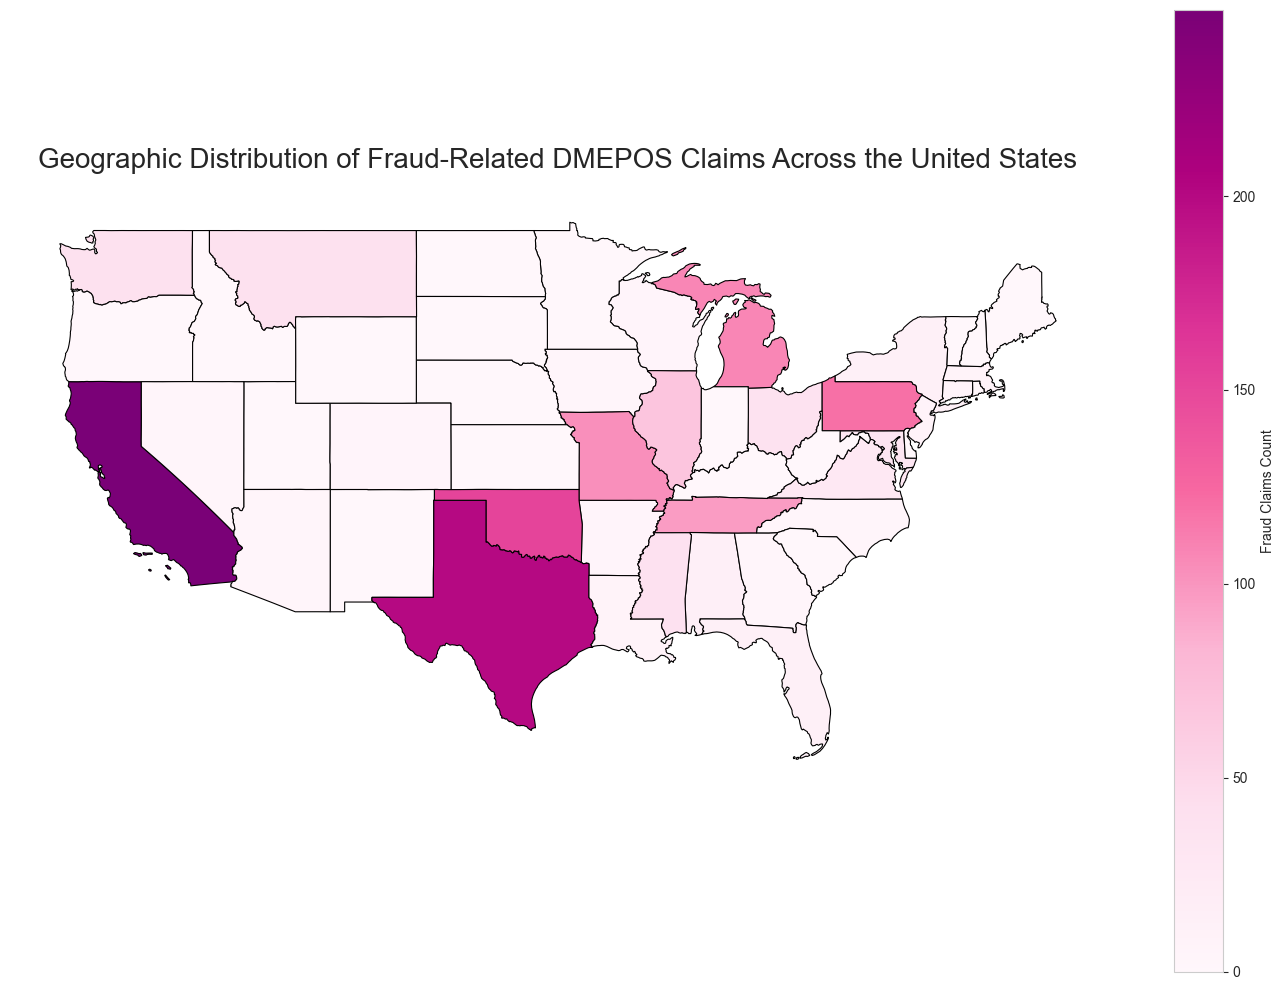

In [18]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

#US shapefile
states = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip")
states = states[~states['STUSPS'].isin(['AK', 'HI', 'PR'])]  # lower 48

pink_cmap = LinearSegmentedColormap.from_list("custom_pink",["#fff7fb", "#fde0ef", "#fbb6d4", "#f768a1", "#dd3497", "#ae017e", "#7a0177"] )

#Only fraud claims
fraud_df = df[df['Excluded'] == 'y'].copy()  # assuming 'y' marks fraud/excluded claims
fraud_df['Rfrg_Prvdr_State_Abrvtn'] = fraud_df['Rfrg_Prvdr_State_Abrvtn'].str.upper()

#Aggregate fraud counts per state
fraud_by_state = fraud_df.groupby('Rfrg_Prvdr_State_Abrvtn').size().reset_index(name='fraud_count')

#Mainland States
fraud_by_state = fraud_by_state[fraud_by_state['Rfrg_Prvdr_State_Abrvtn'].isin(states['STUSPS'])]

# Merging excluded dataframe with shape file
merged = states.merge(fraud_by_state, left_on='STUSPS', right_on='Rfrg_Prvdr_State_Abrvtn', how='left')
merged['fraud_count'] = merged['fraud_count'].fillna(0)

#Plot choropleth
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Setting up min and max vlaue for shade
cmax = merged['fraud_count'].max()
cmin = 0

merged.plot(
    column='fraud_count',
    cmap=pink_cmap,
    linewidth=0.8,
    edgecolor='black',
    ax=ax,
    legend=True,
    vmin=cmin,
    vmax=cmax,
    legend_kwds={'label': "Fraud Claims Count"}
)

ax.set_title(
    "Geographic Distribution of Fraud-Related DMEPOS Claims Across the United States",
    fontsize=20,
    pad=20)

ax.axis('off')
plt.tight_layout()

# Saving Image
plt.savefig("choropleth.png", dpi=800, bbox_inches="tight")
plt.show()


In [19]:
fraud_df['Rfrg_Prvdr_State_Abrvtn']

45923      GA
53118      CA
53119      CA
53120      CA
53121      CA
           ..
4339318    AZ
4351193    WI
4393001    NJ
4393002    NJ
4405259    CA
Name: Rfrg_Prvdr_State_Abrvtn, Length: 1413, dtype: object

In [20]:
#Total unique fraud providers:
total_unique_providers = df['Rfrg_NPI'].nunique()
total_unique_providers

398034

In [21]:
#Total unique fraud providers:
#Unique providers that commited fraud and were flagged

fraud_df = df[df['Excluded'].str.strip().str.lower() == 'y'].copy()
unique_fraud_providers = fraud_df['Rfrg_NPI'].nunique()
unique_fraud_providers


109

In [29]:
#Top 10 states with the most fraud claims
 fraud_by_state.sort_values(by="fraud_count", ascending=False).head(10)

,Rfrg_Prvdr_State_Abrvtn,fraud_count
4,CA,248
26,TX,200
23,OK,153
24,PA,120
14,MI,108
15,MO,103
25,TN,96
10,IL,68
17,MT,40
28,WA,40
